<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1850 | Val: 405 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 4, accumulation steps = 4 (effective batch size ≈ 16, tuned value = 14)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 4 micro-batches per optimizer step (effective batch size ≈ micro_batch x 4).
[DenseNet-121] Epoch   1/100 | LR: 2.74e-04 | train loss 1.2105 acc 0.490 | val loss 1.0878 acc 0.464 *
[DenseNet-121] Epoch   2/100 | LR: 2.74e-04 | train loss 1.0228 acc 0.589 | val loss 0.7075 acc 0.773 *
[DenseNet-121] Epoch   3/100 | LR: 2.74e-04 | train loss 0.9303 acc 0.622 | val loss 1.6083 acc 0.783
[DenseNet-121] Epoch   4/100 | LR: 2.74e-04 | train loss 0.8708 acc 0.638 | val loss 0.9739 acc 0.733
[DenseNet-121] Epoch   5/100 | LR: 2.74e-04 | train loss 0.8537 acc 0.660 | val loss 1.0864 acc 0.699
[DenseNet-121] Epoch   6/100 | LR: 2.74e-04 | train loss 0.7979 acc 0.682 | val loss 0.7154 acc 0.788
[DenseNet-121] Epoch   7/100 | LR: 2.74e-05 | train loss 0.7695 acc 0.683 | val loss 0.9386 acc 0.733
[DenseNet-121] Epoch   8/100 | LR: 2.74e-05 | train loss 0.6199 acc 0.760 | val loss 0.9279 acc 0.758
[DenseNet-121] Epoch   9/100 | LR: 2.74e-05 | train loss 0.

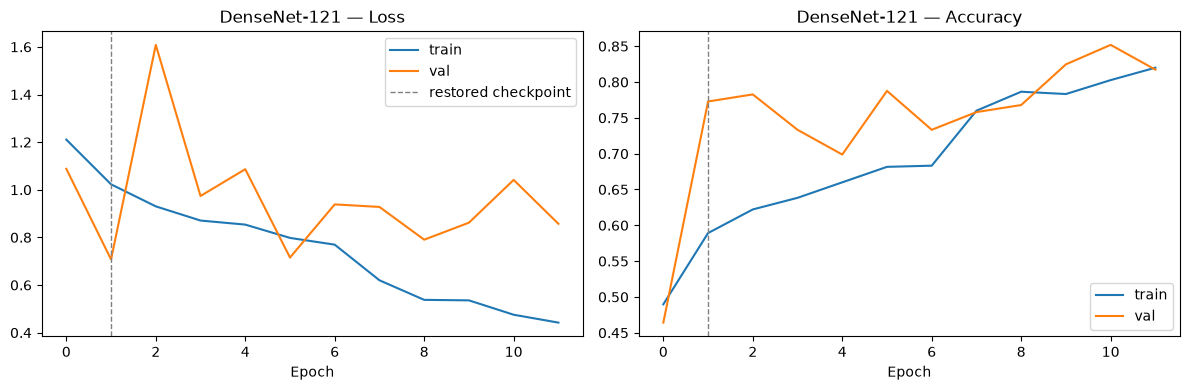

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.583


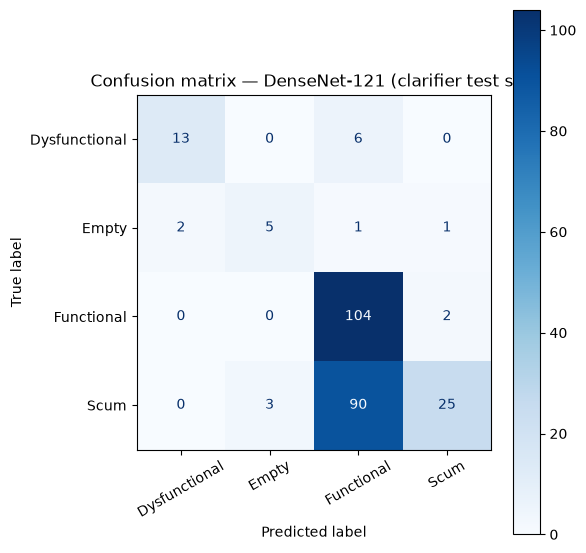

               precision    recall  f1-score   support

Dysfunctional      0.867     0.684     0.765        19
        Empty      0.625     0.556     0.588         9
   Functional      0.517     0.981     0.678       106
         Scum      0.893     0.212     0.342       118

     accuracy                          0.583       252
    macro avg      0.725     0.608     0.593       252
 weighted avg      0.723     0.583     0.524       252



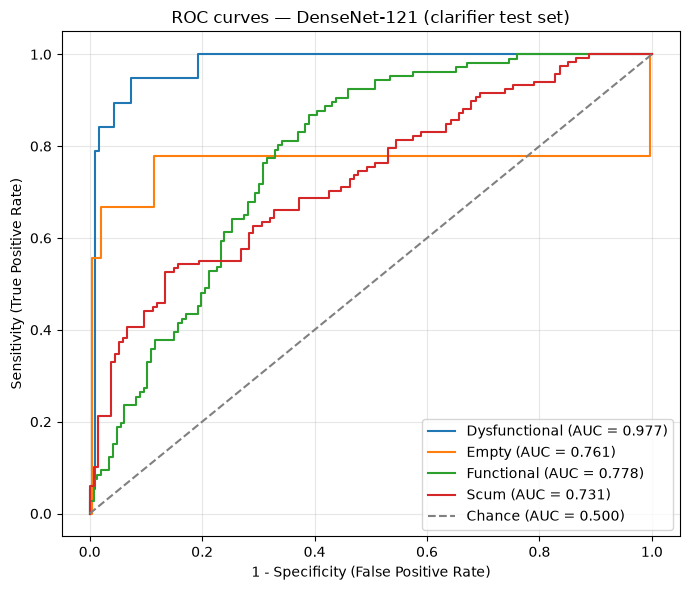

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.977
  Empty          : 0.761
  Functional     : 0.778
  Scum           : 0.731

Mean AUC: 0.812


(np.float64(0.5833333333333334),
 {'Dysfunctional': 0.9765077930878698,
  'Empty': 0.7613168724279835,
  'Functional': 0.7781726544326699,
  'Scum': 0.7307740956235771})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/results_clarifier_densenet121.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
